# CNN–Transformer Pipeline for Reading Spatial Sequences in Images

This notebook is a **teaching template** that demonstrates a clean end-to-end PyTorch workflow for a hybrid model:

- A **CNN** extracts local visual features from an image.
- A **Transformer Encoder** reads those features as a **left-to-right sequence** (tokens along the image width).
- The model predicts **which vertical column bin** contains a bright dot.

Key goals:
- Understand how to turn a 2D feature map `(B, C, H', W')` into a sequence `(B, T=W', D=C)`.
- See what a CNN–Transformer model outputs **at each stage** (with shapes and examples).
- Train with a small training engine that saves:
  - the **current/last** model checkpoint every epoch,
  - the **best** model checkpoint based on validation accuracy,
  - full **CSV logs**, **plots**, and **test results** in a timestamped folder.
- Visualize predictions with **vertical grid lines** so column bins are obvious.

> This is not about achieving the best score.  
> It is about understanding the mechanics and writing clean, inspectable code.


## 1) Setup (imports, device, reproducibility)

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import random
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

torch.set_printoptions(precision=4, sci_mode=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


Device: cuda


## 2) Problem definition

We generate RGB images of size `H×W`. Each image contains a small bright dot located in exactly one of `N_BINS` vertical columns.

- The **label** is the index of the column bin: `0, 1, ..., N_BINS-1`.
- The model must predict the correct bin.

Why this is a good CNN→sequence→Transformer example:
- The dot is a **local** pattern (CNN is good at local feature extraction).
- The label depends on **horizontal position** (naturally represented as a sequence along the width).
- A Transformer can model **global relationships** between all positions in the width sequence.


## 3) On-the-fly dataset with deterministic samples per index

In [2]:
@dataclass
class DotSeqConfig:
    height: int = 64
    width: int = 64
    n_bins: int = 8
    dot_radius: int = 2
    background_noise_std: float = 0.03
    dot_intensity: float = 1.0  # 1.0 = white dot in [0,1]
    base_seed: int = 123  # makes sample idx deterministic

class DotInColumnDataset(Dataset):
    """Generate RGB images on the fly, but deterministically per index.

    Deterministic per index means:
    - index i always produces the same image/label
    - train/val/test splits are reproducible
    """
    def __init__(self, length: int, cfg: DotSeqConfig):
        self.length = length
        self.cfg = cfg

    def __len__(self) -> int:
        return self.length

    def _rng_for_index(self, idx: int) -> np.random.Generator:
        return np.random.default_rng(self.cfg.base_seed + idx)

    def __getitem__(self, idx: int):
        rng = self._rng_for_index(idx)
        H, W = self.cfg.height, self.cfg.width
        n_bins = self.cfg.n_bins

        # Pick which vertical bin contains the dot
        label = int(rng.integers(0, n_bins))

        # Compute x-range for that bin
        bin_w = W / n_bins
        x0 = int(label * bin_w)
        x1 = int((label + 1) * bin_w) - 1

        # Choose a dot center inside the bin and away from borders
        r = self.cfg.dot_radius
        cx = int(rng.integers(max(r, x0), min(x1, W - r - 1) + 1))
        cy = int(rng.integers(r, H - r - 1))

        # Background: noise, then clipped to [0,1]
        img = rng.normal(loc=0.0, scale=self.cfg.background_noise_std, size=(H, W, 3)).astype(np.float32)
        img = np.clip(img, 0.0, 1.0)

        # Draw a filled disk (circle) for the dot
        yy, xx = np.ogrid[:H, :W]
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        img[mask] = self.cfg.dot_intensity

        # Convert to torch tensor: (C,H,W)
        x = torch.from_numpy(img).permute(2, 0, 1).contiguous()
        y = torch.tensor(label, dtype=torch.long)
        return x, y


## 4) Train/validation/test split (stratified)

Even though the dataset is generated on the fly, each index has a fixed label.
So we can:
- collect labels for all indices once,
- do a stratified split over indices,
- and then use `Subset`.


In [3]:
from sklearn.model_selection import train_test_split

cfg = DotSeqConfig(height=64, width=64, n_bins=8, dot_radius=2, background_noise_std=0.03, base_seed=123)

N = 6000
full_ds = DotInColumnDataset(length=N, cfg=cfg)

# Collect labels for stratification
labels = np.array([int(full_ds[i][1].item()) for i in range(N)])
indices = np.arange(N)

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, stratify=labels)
temp_labels = labels[temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=temp_labels)

print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

def dist(name, idx):
    c = np.bincount(labels[idx], minlength=cfg.n_bins)
    print(f"{name:5s}", c, "sum=", c.sum())

dist("train", train_idx)
dist("val", val_idx)
dist("test", test_idx)


Split sizes: 4200 900 900
train [489 513 564 498 527 564 512 533] sum= 4200
val   [105 110 121 107 113 121 109 114] sum= 900
test  [105 110 121 106 112 121 110 115] sum= 900


## 5) DataLoaders

In [4]:
batch_size = 64

train_loader = DataLoader(Subset(full_ds, train_idx), batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(Subset(full_ds, val_idx),   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(Subset(full_ds, test_idx),  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch x:", xb.shape, "Batch y:", yb.shape)


Batch x: torch.Size([64, 3, 64, 64]) Batch y: torch.Size([64])


## 6) Visualization helper with vertical bin lines

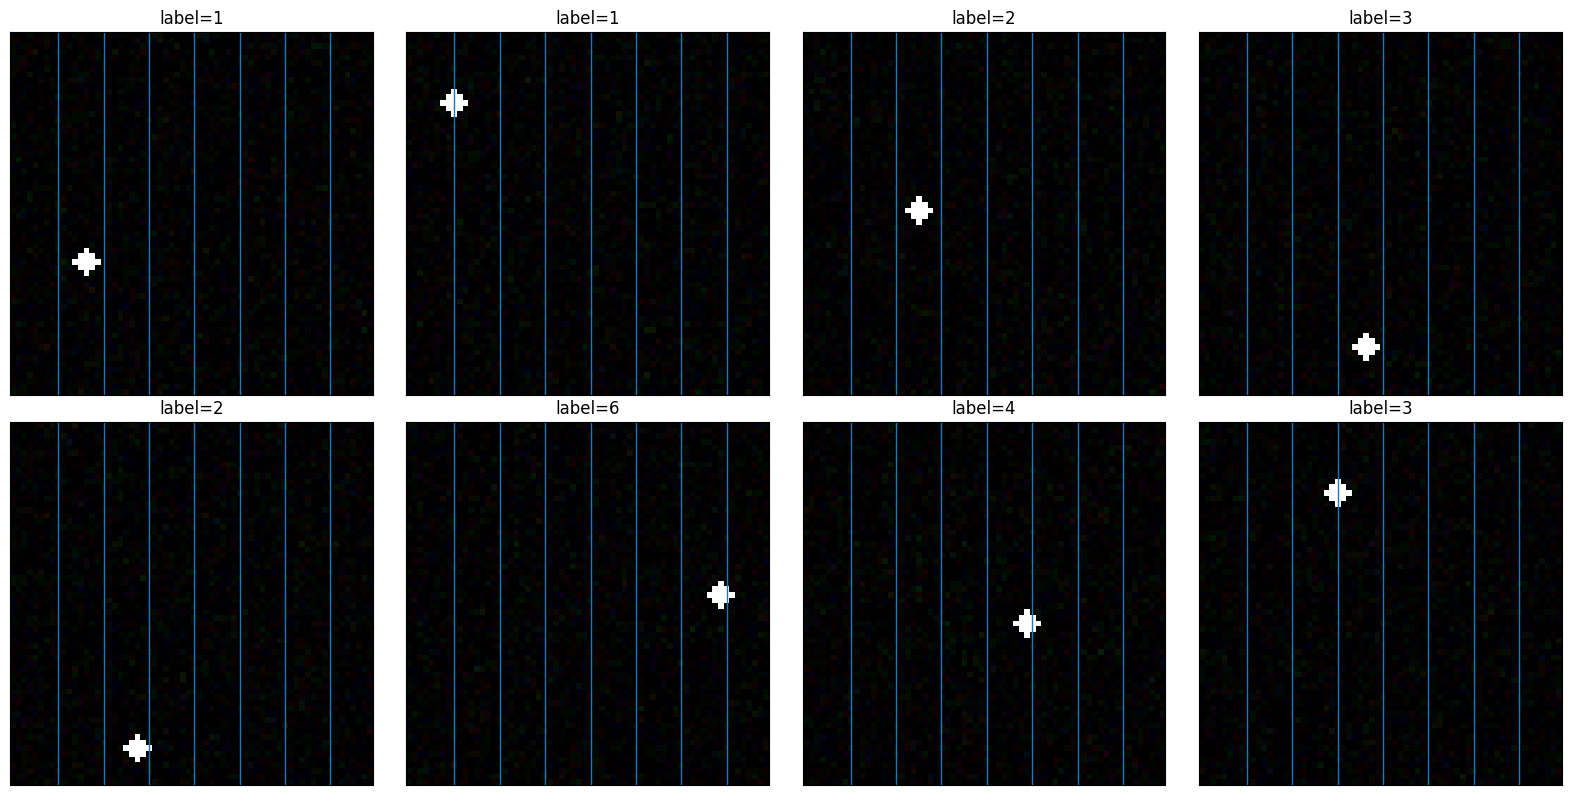

In [5]:
def show_with_bins(img_tensor_chw: torch.Tensor, n_bins: int, title: str = "", ax=None):
    """img_tensor_chw: (3,H,W) in [0,1]. Draw vertical bin boundaries."""
    img = img_tensor_chw.permute(1,2,0).detach().cpu().numpy()
    H, W, _ = img.shape

    if ax is None:
        ax = plt.gca()

    ax.imshow(img)
    for k in range(1, n_bins):
        x = k * W / n_bins
        ax.axvline(x=x, linewidth=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

def show_samples(loader, n=8, ncols=4):
    xb, yb = next(iter(loader))
    n = min(n, xb.size(0))
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))
    for i in range(n):
        ax = plt.subplot(nrows, ncols, i+1)
        show_with_bins(xb[i], cfg.n_bins, title=f"label={int(yb[i])}", ax=ax)
    plt.tight_layout()
    plt.show()

show_samples(train_loader, n=8, ncols=4)


## 7) A baseline CNN–Transformer model

### Key idea: convert feature map to tokens

A CNN produces a feature map:
- `feat`: `(B, C, H', W')`

To read left-to-right, we convert it to a token sequence along the width:
1. Average over height `H'`: `(B, C, W')`
2. Transpose to `(B, W', C)` so tokens are ordered by x-position.

Then a Transformer Encoder reads the tokens:
- output: `(B, W', C)` (same shape, but each token becomes context-aware)

Finally we classify using:
- last token OR mean pooling over tokens (we show both; we use mean pooling by default).


In [ ]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_ch: int = 3, feat_ch: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32
            nn.Conv2d(16, feat_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16
        )

    def forward(self, x):
        return self.net(x)  # (B, feat_ch, 16, 16)

class CNNTransformerClassifier(nn.Module):
    def __init__(
        self,
        n_bins: int,
        feat_ch: int = 64, #32,
        nhead: int = 8, #4,
        num_layers: int = 4, #2,
        dim_feedforward: int = 256, #128,
        dropout: float = 0.1,
        pooling: str = "last",  # "mean" or "last"
        use_positional_encoding: bool = False, #True,
        max_tokens: int = 256,
    ):
        super().__init__()
        self.cnn = CNNFeatureExtractor(in_ch=3, feat_ch=feat_ch)
        self.pooling = pooling
        self.use_pos = use_positional_encoding

        # A learnable positional embedding for token positions along width
        # We keep a maximum length and slice to the actual token length W'.
        if self.use_pos:
            self.pos_embed = nn.Parameter(torch.zeros(1, max_tokens, feat_ch))
            nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=feat_ch,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,  # tokens are (B,T,D)
            activation="gelu",
            norm_first=True,   # "Pre-LN" style (often more stable)
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.head = nn.Linear(feat_ch, n_bins)

    def forward(self, x, return_intermediates: bool = False):
        # 1) CNN features: (B, C, H', W')
        feat = self.cnn(x)

        # 2) Feature map -> tokens along width:
        #    mean over height: (B, C, W')
        tokens = feat.max(dim=2).values

        #    transpose to (B, T=W', D=C)
        tokens = tokens.transpose(1, 2)

        # 3) Add positional embedding (optional)
        if self.use_pos:
            T = tokens.size(1)
            tokens = tokens + self.pos_embed[:, :T, :]

        # 4) Transformer encoder over tokens: (B, T, D)
        enc = self.encoder(tokens)

        # 5) Pool tokens -> one vector
        if self.pooling == "last":
            pooled = enc[:, -1, :]
        elif self.pooling == "mean":
            pooled = enc.mean(dim=1)
        else:
            raise ValueError("pooling must be 'mean' or 'last'")

        logits = self.head(pooled)

        if return_intermediates:
            return logits, feat, tokens, enc, pooled
        return logits

model = CNNTransformerClassifier(
    n_bins=cfg.n_bins,
    feat_ch=32,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    pooling="mean",
    use_positional_encoding=True,
    max_tokens=256,
).to(device)

with torch.no_grad():
    xb, yb = next(iter(train_loader))
    xb = xb.to(device)
    logits, feat, tokens, enc, pooled = model(xb, return_intermediates=True)

print("Input:", xb.shape)
print("CNN feat:", feat.shape, "      (B,C,H',W')")
print("Tokens:", tokens.shape, "       (B,T=W',D=C)")
print("Encoder out:", enc.shape, "   (B,T,D)")
print("Pooled:", pooled.shape, "      (B,D)")
print("Logits:", logits.shape, "      (B,n_bins)")


/tmp/ipykernel_1682381/2241032891.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Input: torch.Size([64, 3, 64, 64])
CNN feat: torch.Size([64, 32, 16, 16])       (B,C,H',W')
Tokens: torch.Size([64, 16, 32])        (B,T=W',D=C)
Encoder out: torch.Size([64, 16, 32])    (B,T,D)
Pooled: torch.Size([64, 32])       (B,D)
Logits: torch.Size([64, 8])       (B,n_bins)


## 8) Training engine (timestamped folder, logs, last/best checkpoints, plots, test results)

This section rewrites the training loop so it saves outputs like a competitor-style framework:

- Create a unique directory: `runs/<ModelName>_<timestamp>/`
- Save:
  - `current_model.pt` each epoch (overwrite)
  - `best_model.pt` when validation accuracy improves
  - `log.csv` with `epoch,train_loss,val_loss,val_acc`
  - `training_plot.png` (loss curves + val accuracy)
  - `test_results.csv` (final test accuracy for best model)
  - prediction grids (PNG) for both best and last checkpoints


In [7]:
from dataclasses import dataclass
from typing import Dict, Tuple

@dataclass
class EpochStats:
    loss: float
    acc: float

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> EpochStats:
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, yb)
        n_batches += 1

    return EpochStats(loss=total_loss / n_batches, acc=total_acc / n_batches)

def plot_training_curves(log_csv: Path, out_png: Path):
    df = pd.read_csv(log_csv)
    fig = plt.figure(figsize=(10, 4))

    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(df["epoch"], df["train_loss"], label="Train Loss")
    ax1.plot(df["epoch"], df["val_loss"], label="Val Loss")
    ax1.set_title("Loss History")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True)
    ax1.legend()

    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(df["epoch"], df["val_acc"], marker="o")
    ax2.set_title("Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.grid(True)

    plt.tight_layout()
    fig.savefig(out_png, dpi=150)
    plt.show()

@torch.no_grad()
def save_prediction_grid(model: nn.Module, loader: DataLoader, save_path: Path, n_bins: int, n: int = 12, ncols: int = 4):
    model.eval()
    xb, yb = next(iter(loader))
    xb = xb.to(device)
    yb = yb.to(device)

    logits = model(xb)
    preds = logits.argmax(dim=1)

    n = min(n, xb.size(0))
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))

    for i in range(n):
        ax = plt.subplot(nrows, ncols, i+1)
        title = f"true={int(yb[i])}  pred={int(preds[i])}"
        show_with_bins(xb[i].cpu(), n_bins, title=title, ax=ax)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

def train_competitor_style(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int = 8,
    lr: float = 1e-3,
    out_root: str = "runs",
) -> Path:
    # 1) Setup directories
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_name = model.__class__.__name__
    save_dir = Path(out_root) / f"{model_name}_{timestamp}"
    save_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir = save_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n🚀 STARTING TRAINING: {model_name}")
    print(f"📂 Saving results to: {save_dir}")

    # 2) Loss + optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # 3) Log file
    log_path = save_dir / "log.csv"
    with open(log_path, "w") as f:
        f.write("epoch,train_loss,val_loss,val_acc\n")

    best_acc = -1.0

    # --- EPOCH LOOP ---
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", unit="batch")
        for xb, yb in pbar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            n_batches += 1
            pbar.set_postfix(loss=float(loss.item()))

        avg_train_loss = train_loss / n_batches

        # Validation
        val_stats = evaluate_model(model, val_loader, criterion)
        avg_val_loss = val_stats.loss
        val_acc = val_stats.acc * 100.0

        print(f"Epoch {epoch:02d} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | val_acc={val_acc:.2f}%")

        # Logging
        with open(log_path, "a") as f:
            f.write(f"{epoch},{avg_train_loss:.6f},{avg_val_loss:.6f},{val_acc:.4f}\n")

        # Save checkpoints
        current_path = ckpt_dir / "current_model.pt"
        best_path = ckpt_dir / "best_model.pt"

        torch.save(model.state_dict(), current_path)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)

    print(f"🏆 Training finished! Best validation accuracy: {best_acc:.2f}%")

    # --- FINAL TEST EVALUATION (BEST MODEL) ---
    best_path = ckpt_dir / "best_model.pt"
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_stats = evaluate_model(model, test_loader, criterion)
    test_acc = test_stats.acc * 100.0
    print(f"✅ Final TEST accuracy (best model): {test_acc:.2f}%")

    # Save test results
    test_csv = save_dir / "test_results.csv"
    with open(test_csv, "w") as f:
        f.write("model_version,test_acc\n")
        f.write(f"best_model,{test_acc:.4f}\n")

    # Plot curves
    plot_training_curves(log_path, save_dir / "training_plot.png")

    # Save prediction grids for best and last
    # Best:
    model.load_state_dict(torch.load(ckpt_dir / "best_model.pt", map_location=device))
    save_prediction_grid(model, test_loader, save_dir / "predictions_best.png", cfg.n_bins, n=12, ncols=4)

    # Last/current:
    model.load_state_dict(torch.load(ckpt_dir / "current_model.pt", map_location=device))
    save_prediction_grid(model, test_loader, save_dir / "predictions_last.png", cfg.n_bins, n=12, ncols=4)

    return save_dir


## 9) Train the CNN–Transformer model

/tmp/ipykernel_1682381/2241032891.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)



🚀 STARTING TRAINING: CNNTransformerClassifier
📂 Saving results to: runs/CNNTransformerClassifier_2026-04-19_15-22-39


Epoch 1/8:   0%|          | 0/66 [00:00<?, ?batch/s]

Epoch 01 | train_loss=1.9515 | val_loss=1.0141 | val_acc=64.69%


Epoch 2/8:   0%|          | 0/66 [00:00<?, ?batch/s]

...

Epoch 06 | train_loss=0.0013 | val_loss=0.0002 | val_acc=100.00%


Epoch 7/8:   0%|          | 0/66 [00:00<?, ?batch/s]

Epoch 07 | train_loss=0.0008 | val_loss=0.0002 | val_acc=100.00%


Epoch 8/8:   0%|          | 0/66 [00:00<?, ?batch/s]

Epoch 08 | train_loss=0.0006 | val_loss=0.0001 | val_acc=100.00%
🏆 Training finished! Best validation accuracy: 100.00%
✅ Final TEST accuracy (best model): 100.00%


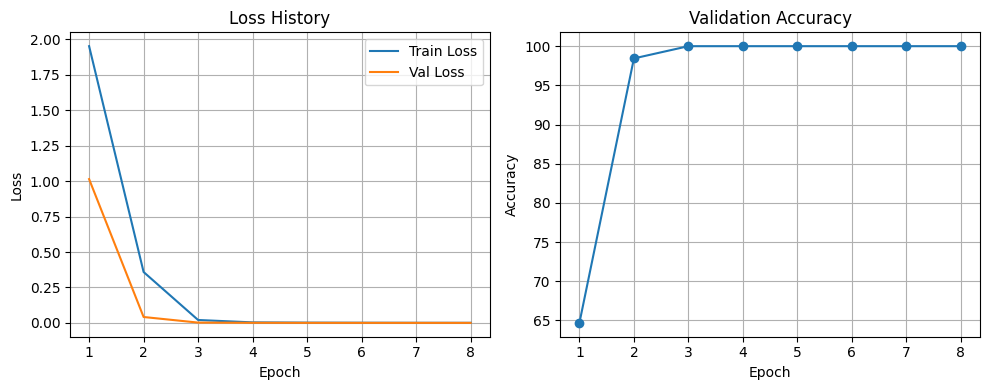

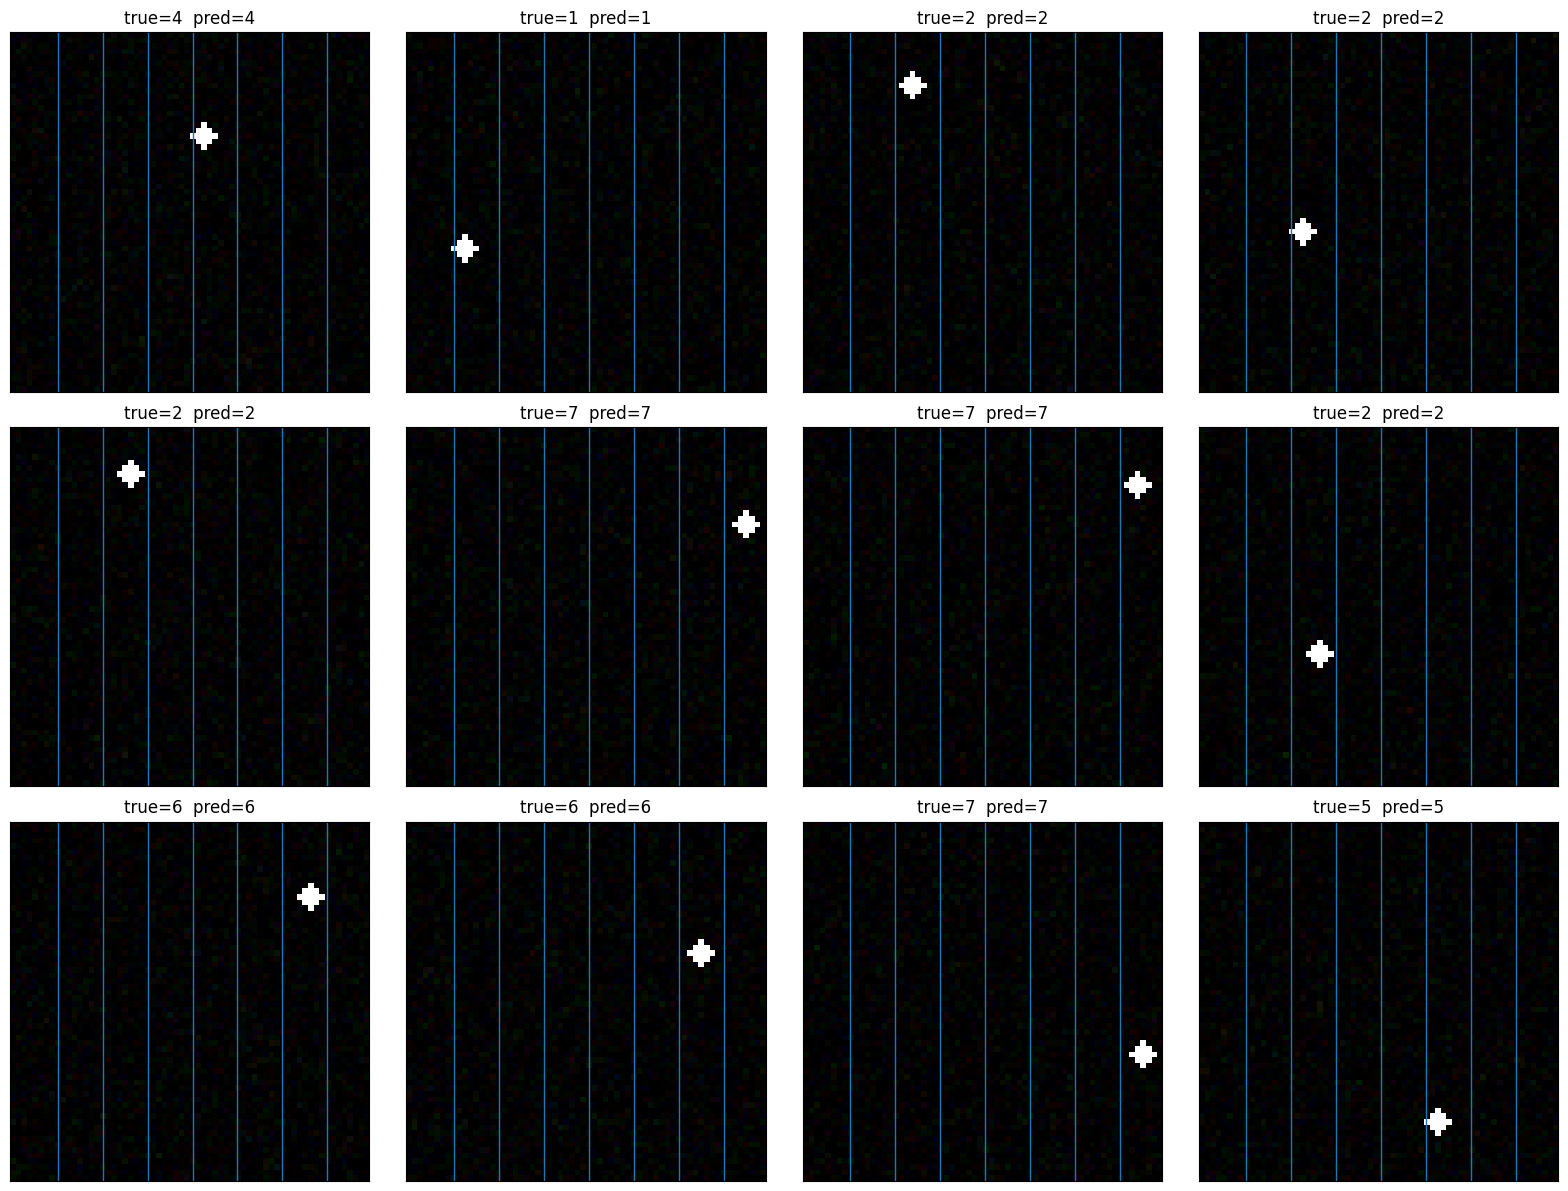

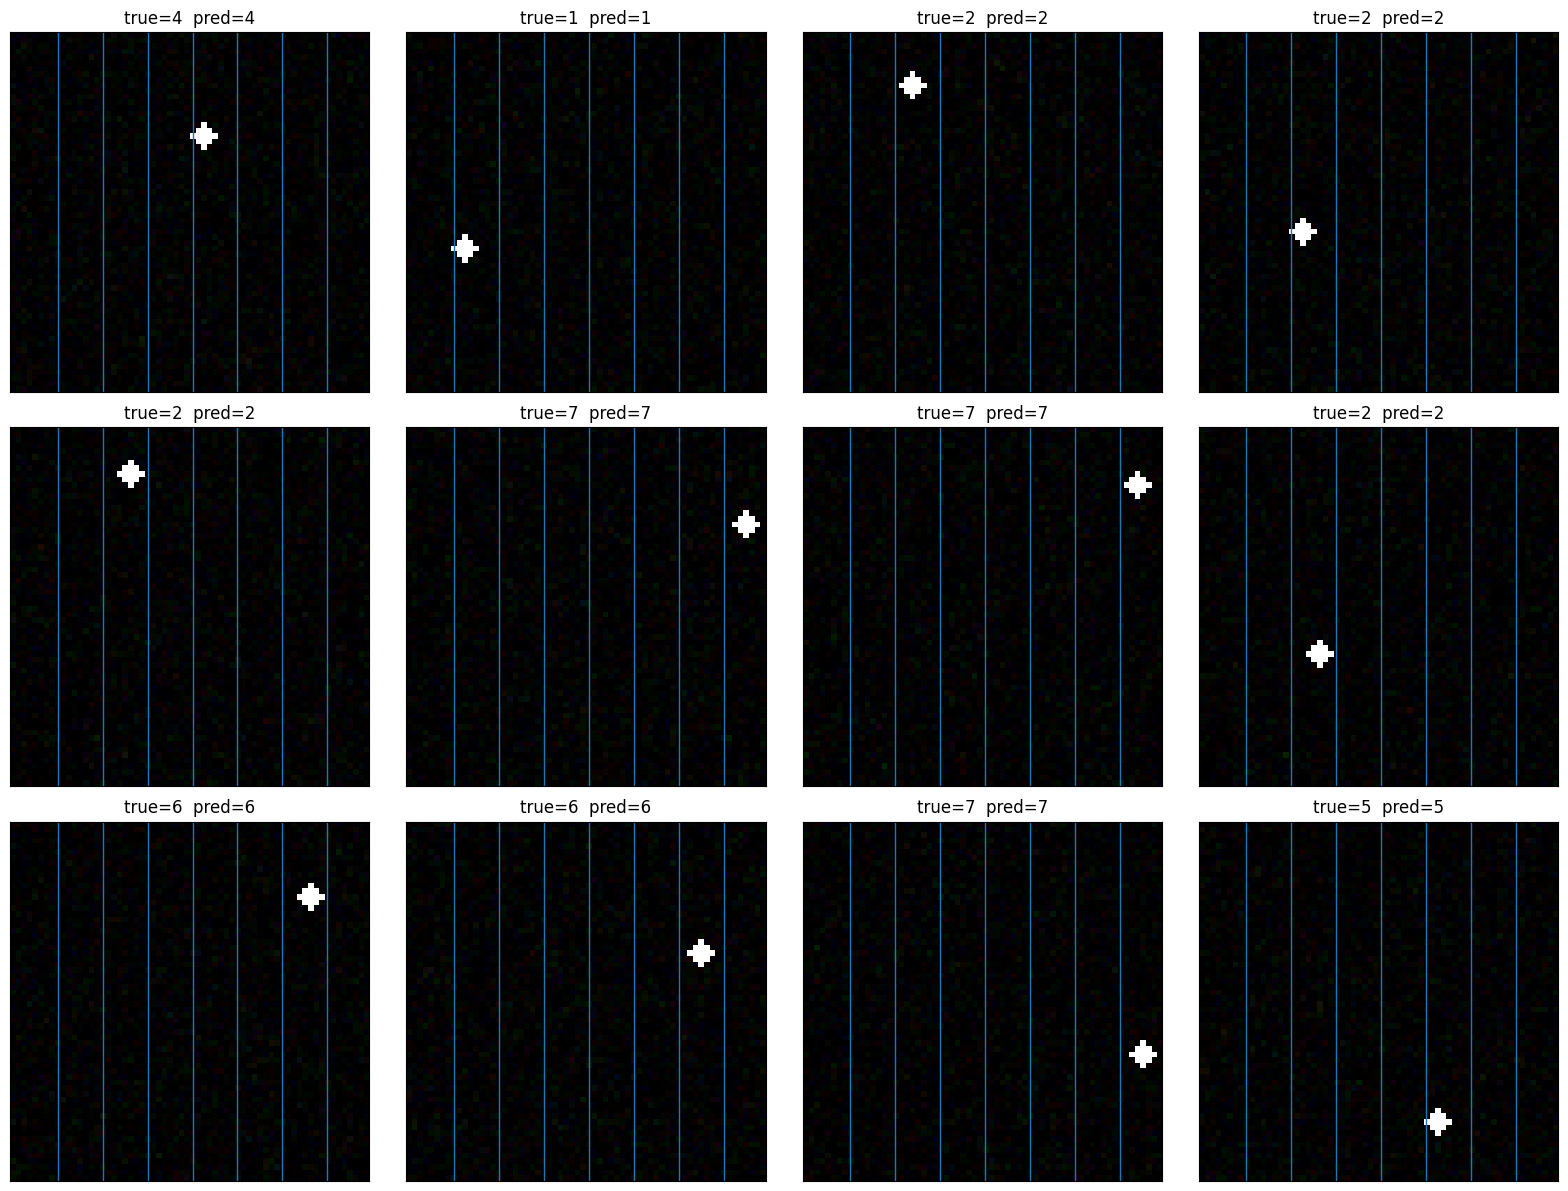

All artifacts saved in: runs/CNNTransformerClassifier_2026-04-19_15-22-39


In [8]:
# Create a fresh model instance for training
model = CNNTransformerClassifier(
    n_bins=cfg.n_bins,
    feat_ch=32,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    pooling="mean",
    use_positional_encoding=True,
    max_tokens=256,
).to(device)

save_dir = train_competitor_style(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=8,
    lr=1e-3,
    out_root="runs",
)

print("All artifacts saved in:", save_dir)


## 10) Suggestions for experiments (Transformer-focused)

Try modifying the baseline and observe how curves and predictions change:

1) **Transformer capacity**
- Increase `num_layers` (e.g., 2 → 4)
- Increase `dim_feedforward` (e.g., 128 → 256)
- Increase `feat_ch` (e.g., 32 → 64) and adjust `nhead`

2) **Attention heads**
- Change `nhead` (e.g., 2, 4, 8) — must divide `feat_ch`

3) **Pooling choice**
- Compare `pooling="mean"` vs `pooling="last"`

4) **Positional encoding**
- Turn off positional embeddings and see what happens: `use_positional_encoding=False`

5) **Sequence construction**
- Use `max over height` instead of `mean over height`:
  - replace `feat.mean(dim=2)` with `feat.max(dim=2).values`
